In [15]:
import torch
from utils.models import Daowa_maadPrueba
from utils.inference import prediccionPrueba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = Daowa_maadPrueba(num_clases = 1)

def load_predict(
    modelo,
    state_dict:str,
    device:torch.device,
    dir_path:str,
    filename:str
):
    if not device:
        device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
        
    _state_dict = torch.load(state_dict, map_location=device)
    modelo.load_state_dict(_state_dict, strict = False)
    modelo.to(device)
    prediccionPrueba(modelo, dir_path, filename, device)

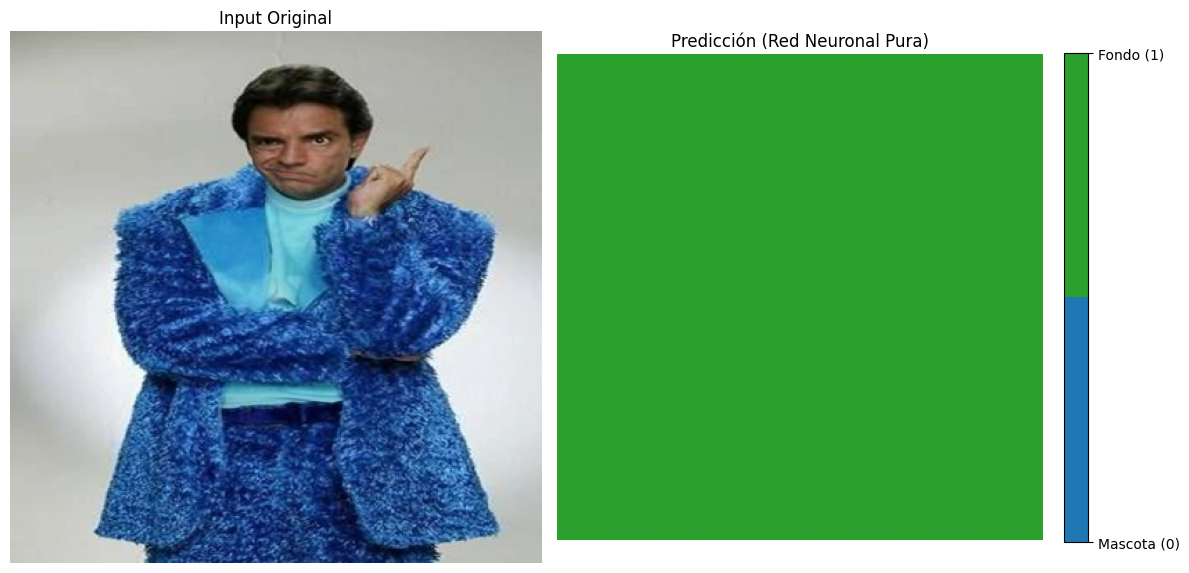

In [12]:
load_predict(modelo, "models/BestScore_2026-04-11_binary.pth", device, "data/hard_negatives/fur_coats", 'descarga (7).jpg')

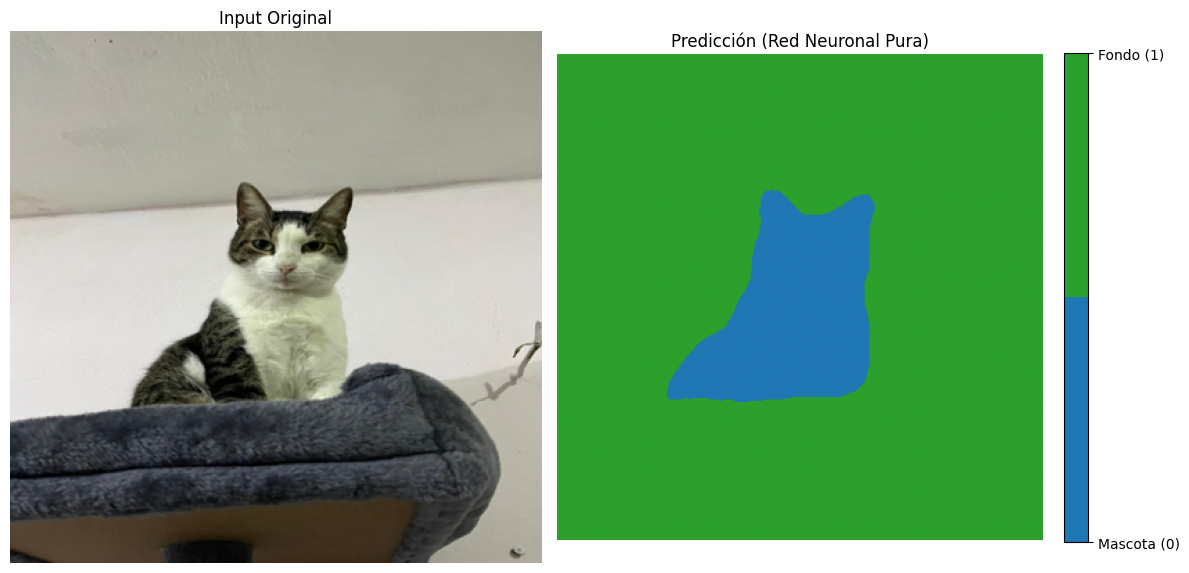

In [37]:
load_predict(modelo, "models/BestIoU_2026-04-11_binary.pth", device, "data/dogVScat/cat", 'guero.jpeg')

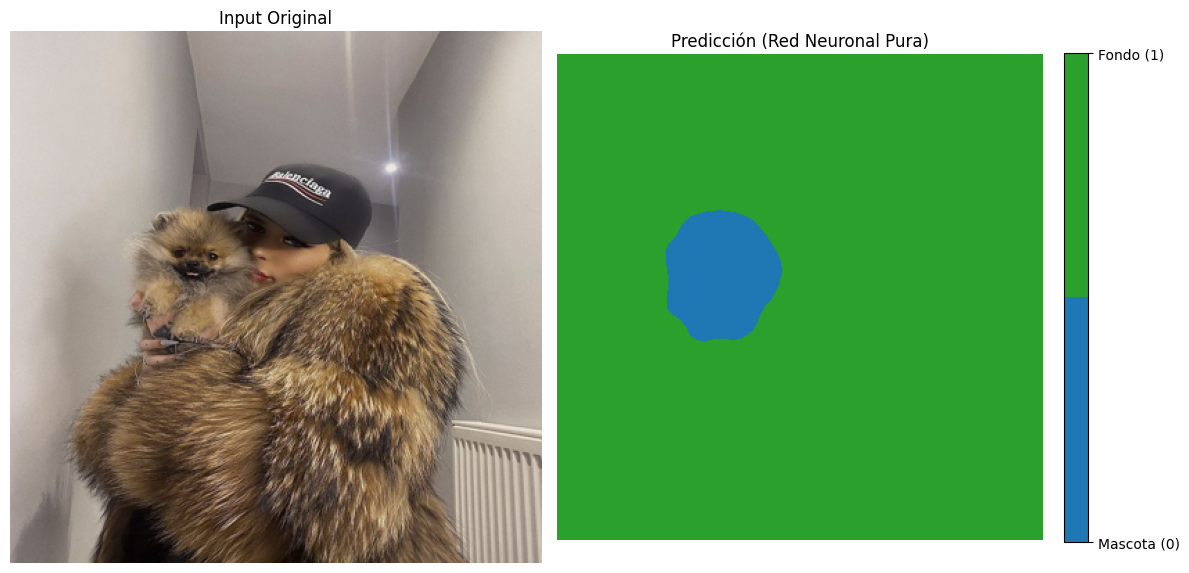

In [33]:
load_predict(modelo, "models/BestScore_Adv_2026-05-15_0.866.pth", device, "data/hard_negatives/fur_coats", 'hard_neg_5cdb0929.jpg')

In [35]:
from utils.train.trainer_adversarial_v2 import evaluate_model
from utils.train import get_adversarial_dataloaders
import pandas as pd

df_oxford   = pd.read_csv("labels/dataset_generated.csv")
df_ade20k   = pd.read_csv("labels/ade20k_adversarial_train.csv")
df_personas = pd.read_csv("labels/ade20k_person_negatives.csv")  # ← nuevo
loaders = get_adversarial_dataloaders(
    df_oxford=df_oxford,
    df_ade20k=df_ade20k,
    df_personas=df_personas,          # ← nuevo
    oxford_dir="data/oxford",
    ade20k_dir="data/ADEChallengeData2016",
    batch_size=16,
    num_pos_per_batch=13,
    img_size=(256, 256),              # rápido para probar
    val_split=0.1,
    test_split=0.1,
)

_state_dict = torch.load("models/BestScore_Adv_2026-05-13_0.984.pth", map_location=device)
modelo.load_state_dict(_state_dict, strict = False)
modelo.to(device)
evaluate_model(modelo, loaders['test'], device = device)

ℹ️  Personas añadidas como hard negatives: 1515 train | 190 val | 189 test
✅ DataLoader adversarial listo — 5666 positivos | 9385 negativos | 435 batches/época (13P + 3N por batch)
✅ DataLoaders adversariales listos —
   Train : 5666 pos + 9385 neg
   Val   : 708 pos + 1174 neg
   Test  : 709 pos + 1172 neg
Evaluando sobre 471 batches...
✅ Evaluación completa:
   Val Loss : 0.9559
   IoU Pos  : 0.5336   Acc Pos: 53.4%
   IoU Neg  : 1.0000   Acc Neg: 100.0%
   Score    : 0.8601  (0.7×IoU_Neg + 0.3×IoU_Pos)


{'val_loss': 0.955916,
 'iou_pos': 0.5336,
 'iou_neg': 1.0,
 'acc_pos': 53.36,
 'acc_neg': 100.0,
 'score': 0.8601}

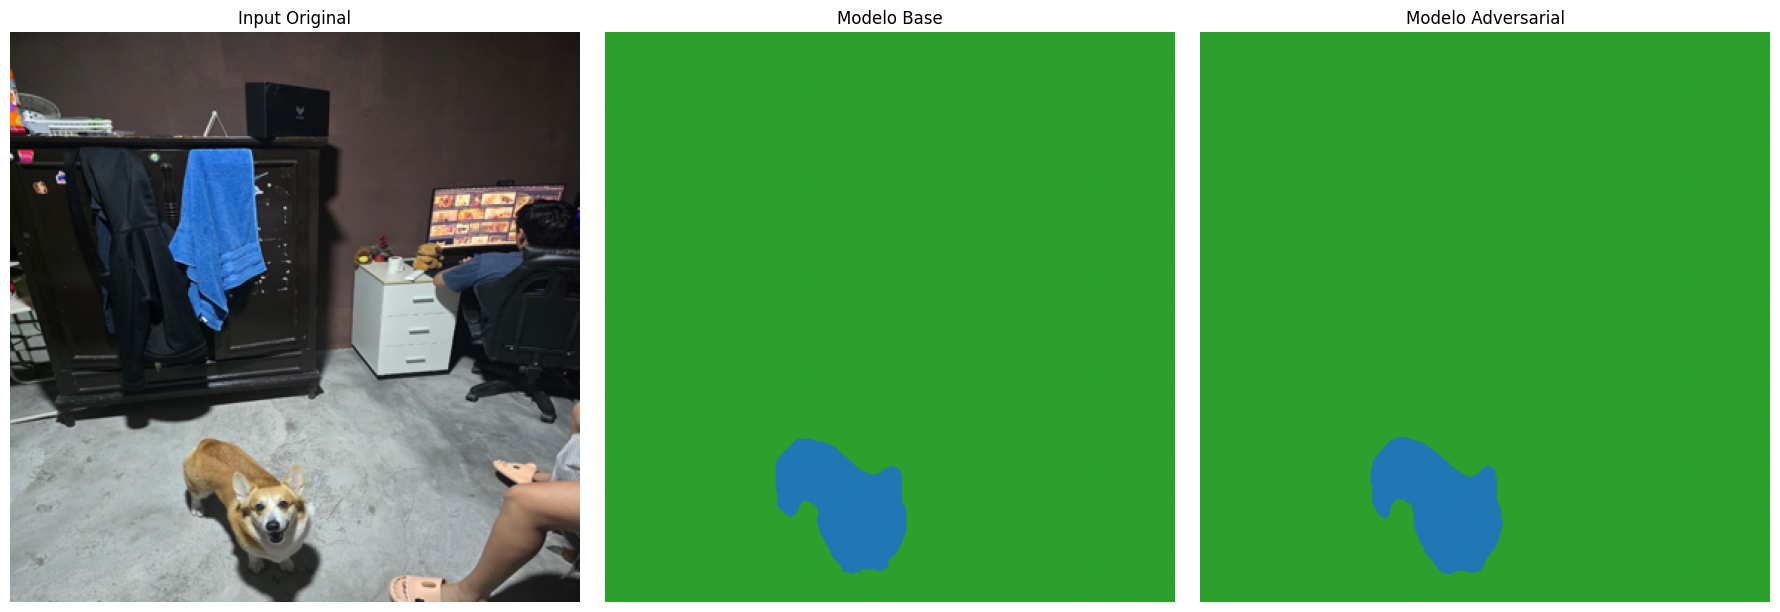

In [60]:
from utils.inference.predict import comparar_modelos

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Cargar el modelo base (el de abril que fallaba)
modelo_base = Daowa_maadPrueba(num_clases=1)
modelo_base.load_state_dict(torch.load("models/BestScore_2026-04-11_binary.pth", map_location=device))

# 2. Cargar el modelo adversarial (el de hoy que es robusto)
modelo_adv = Daowa_maadPrueba(num_clases=1)
modelo_adv.load_state_dict(torch.load("models/BestScore_Adv_2026-05-15_0.866.pth", map_location=device))

# 3. Comparar directamente en la imagen problemática
comparar_modelos(modelo_base, modelo_adv, "data/dogVScat/dog", 'random.jpeg', device)


In [ ]:
#Celda 2 — Datos
import pandas as pd
from utils.train import get_adversarial_dataloaders, train_model
from utils.models import Daowa_maadPrueba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

df_oxford   = pd.read_csv("labels/dataset_generated.csv")
df_ade20k   = pd.read_csv("labels/ade20k_adversarial_train.csv")
df_personas = pd.read_csv("labels/ade20k_person_negatives.csv")  # ← nuevo

df_ade20k   = df_ade20k.rename(columns={"image": "file"})
df_personas = df_personas.rename(columns={"image": "file"})

if 'is_gold' in df_oxford.columns:
    df_oxford = df_oxford[df_oxford['is_gold'] == False]

loaders = get_adversarial_dataloaders(
    df_oxford=df_oxford,
    df_ade20k=df_ade20k,
    df_personas=df_personas,          # ← nuevo
    oxford_dir="data/oxford",
    ade20k_dir="data/ADEChallengeData2016",
    batch_size=16,
    num_pos_per_batch=13,
    img_size=(256, 256),              # rápido para probar
    val_split=0.1,
    test_split=0.1,
)


In [ ]:
from utils.train.trainer_adversarial_v2 import predict_random_samples

# Asumiendo que ya tienes cargado 'modelo_adv' y creaste tus dataloaders
# predict_random_samples te genera una cuadrícula de (Input | Ground Truth | Predicción)



fig = predict_random_samples(modelo_adv, loaders["test"], device, n_samples=6)
fig.savefig('linkedin_grid.png', dpi=150, bbox_inches='tight')


Cargando SAM en cuda...
Se abrió una ventana emergente. Haz clic en el perro y presiona ENTER...


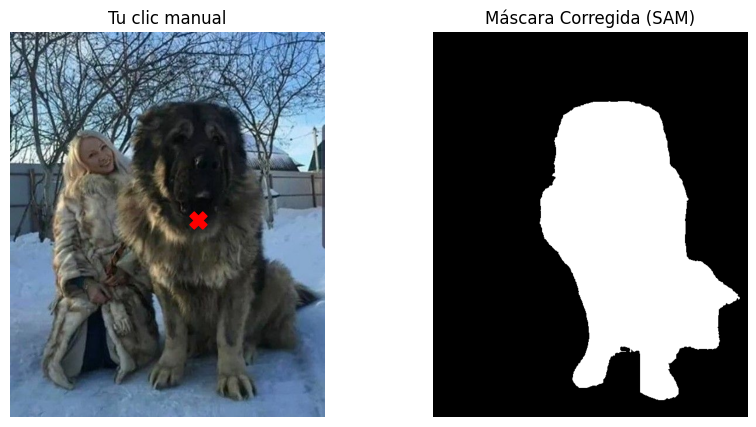

¡Máscara sobrescrita con éxito en: c:\Users\PC\Desktop\Abbadon prueba SAM\source\data\hard_negatives\masks\hard_neg_8344276d.png!


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import torch

# Como estás en source/prueba.ipynb, tu directorio actual es "source"
source_dir = os.getcwd() 

# 1. Agregar la ruta de los modelos para importar sam_loader
models_path = os.path.join(source_dir, 'utils', 'models')
if models_path not in sys.path:
    sys.path.append(models_path)
    
from sam_loader import load_sam

# 2. Cargar SAM
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Cargando SAM en {device}...")
sam_predictor = load_sam(model_type="tiny", device=device)

# --- CONFIGURA TU IMAGEN AQUÍ ---
img_filename = "hard_neg_8344276d.jpg" # <--- CAMBIA ESTO
img_path = os.path.join(source_dir, "data", "hard_negatives", "fur_coats", img_filename)
mask_output_path = os.path.join(source_dir, "data", "hard_negatives", "masks", img_filename.replace('.jpg', '.png'))

# 3. Leer Imagen
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
sam_predictor.set_image(img_rgb)

# 4. Interfaz de OpenCV para hacer clic manual
clicked_point = []

def mouse_callback(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_point.append([x, y])

cv2.namedWindow("Haz clic en el perro real y presiona ENTER", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Haz clic en el perro real y presiona ENTER", mouse_callback)

print("Se abrió una ventana emergente. Haz clic en el perro y presiona ENTER...")
while True:
    temp_img = img_bgr.copy()
    if len(clicked_point) > 0:
        cv2.circle(temp_img, tuple(clicked_point[-1]), 8, (0, 0, 255), -1) # Puntito rojo
    
    cv2.imshow("Haz clic en el perro real y presiona ENTER", temp_img)
    key = cv2.waitKey(1) & 0xFF
    # Si presiona ENTER (13) o ESC (27)
    if key == 13 or key == 27: 
        break

cv2.destroyAllWindows()

# 5. Generar la máscara a partir de TU clic
if len(clicked_point) > 0:
    x, y = clicked_point[-1]
    input_point = np.array([[x, y]])
    input_label = np.array([1]) # Foreground
    
    masks, scores, _ = sam_predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True
    )
    
    # Tomar la máscara con mejor score de confianza
    best_mask = masks[np.argmax(scores)]
    
    # Formato Oxford (0=Mascota, 1=Fondo)
    mask_uint8 = np.ones_like(best_mask, dtype=np.uint8)
    mask_uint8[best_mask > 0] = 0
    cv2.imwrite(mask_output_path, mask_uint8)
    
    # 6. Mostrar el resultado final directo en el Notebook
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.scatter([x], [y], color='red', marker='X', s=150)
    plt.title("Tu clic manual")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Revertir para visualización humana (0 se vuelve 255/blanco)
    mask_vis = np.zeros_like(mask_uint8)
    mask_vis[mask_uint8 == 0] = 255
    plt.imshow(mask_vis, cmap='gray')
    plt.title("Máscara Corregida (SAM)")
    plt.axis('off')
    plt.show()
    
    print(f"¡Máscara sobrescrita con éxito en: {mask_output_path}!")
else:
    print("No seleccionaste ningún punto. No se generó máscara.")
